# 📊 LSTM Model for Yelp Review Star Rating Prediction
### Deep Learning Project

---

## 📦 Dataset: Yelp Reviews Full
| Property | Detail |
|----------|--------|
| **Name** | Yelp Review Full |
| **Source** | HuggingFace `yelp_review_full` |
| **Size** | 650,000 training + 50,000 test reviews (Medium-Large) |
| **Task** | 5-class star rating prediction (1★ to 5★) |
| **Why unique** | Real restaurant/business reviews with 5 sentiment classes — unlike IMDB's binary labels. More challenging and practical for LSTM. |

**Architecture:** Embedding → SpatialDropout → Bidirectional LSTM → LSTM → Dense → Output

## Step 1 — Install Libraries

In [1]:
!pip install -q tensorflow datasets numpy pandas matplotlib seaborn scikit-learn

## Step 2 — Load Yelp Dataset from HuggingFace

In [8]:
from datasets import load_dataset
import pandas as pd
import numpy as np

print('Loading Yelp Review Full dataset...')
dataset = load_dataset('Yelp/yelp_review_full')

# Convert to pandas
train_df = pd.DataFrame(dataset['train']).sample(n=80000, random_state=42).reset_index(drop=True)
test_df  = pd.DataFrame(dataset['test']).sample(n=10000, random_state=42).reset_index(drop=True)

# Labels are 0-4, convert to 1-5 for readability
train_df['stars'] = train_df['label'] + 1
test_df['stars']  = test_df['label']  + 1

print(f'Train samples : {len(train_df)}')
print(f'Test  samples : {len(test_df)}')
print(f'Classes       : 1★ 2★ 3★ 4★ 5★')
print()
print(train_df[['text', 'stars']].head(3))

Loading Yelp Review Full dataset...


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples : 80000
Test  samples : 10000
Classes       : 1★ 2★ 3★ 4★ 5★

                                                text  stars
0  First of all i'm not a big fan of buffet, i tr...      1
1  Thanks Yelp. I was looking for the words to de...      2
2  Service was so-so. They were receiving a deliv...      3


## Step 3 — Explore the Dataset

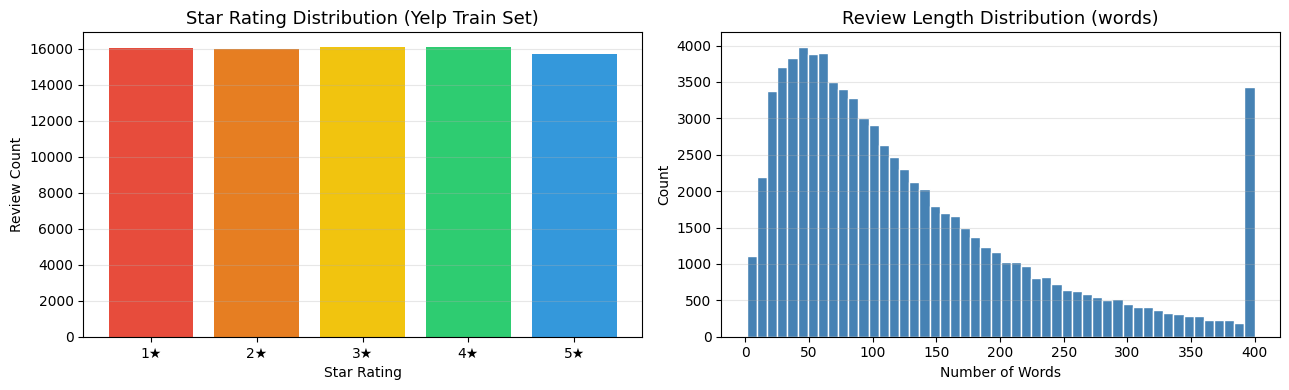

Avg review length: 134 words


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Star distribution
counts = train_df['stars'].value_counts().sort_index()
axes[0].bar([f'{s}★' for s in counts.index], counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Star Rating Distribution (Yelp Train Set)', fontsize=13)
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Review Count')
axes[0].grid(axis='y', alpha=0.3)

# Review length distribution
train_df['length'] = train_df['text'].str.split().str.len()
axes[1].hist(train_df['length'].clip(0, 400), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Review Length Distribution (words)', fontsize=13)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('yelp_eda.png', dpi=150)
plt.show()
print(f'Avg review length: {train_df["length"].mean():.0f} words')

## Step 4 — Text Preprocessing & Tokenization

In [10]:
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB  = 20000   # vocabulary size
MAX_LEN    = 200     # max words per review
NUM_CLASSES = 5

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)           # remove HTML
    text = re.sub(r'[^a-z0-9\s]', '', text)    # keep letters/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Cleaning text...')
X_train_text = [clean_text(t) for t in train_df['text']]
X_test_text  = [clean_text(t) for t in test_df['text']]

# Tokenize
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Labels: 0-indexed for categorical
y_train = train_df['label'].values
y_test  = test_df['label'].values

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'Vocabulary size: {len(tokenizer.word_index)}')
print('✅ Preprocessing done.')

Cleaning text...
X_train shape : (80000, 200)
X_test  shape : (10000, 200)
Vocabulary size: 187332
✅ Preprocessing done.


## Step 5 — Build Bidirectional LSTM Model

In [11]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

def build_bilstm_model():
    inp = Input(shape=(MAX_LEN,), name='input_layer')

    # Embedding: maps word IDs to dense vectors
    x = layers.Embedding(MAX_VOCAB, 128, name='embedding')(inp)
    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(x)

    # Bidirectional LSTM — reads text forward AND backward
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, name='lstm_1'),
        name='bilstm_1'
    )(x)

    # Second LSTM — extract final sequence features
    x = layers.LSTM(64, name='lstm_2')(x)
    x = layers.Dropout(0.3, name='dropout')(x)

    # Dense layers
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)

    # Output: 5 classes (1★ to 5★)
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_bilstm_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,909,829 (11.10 MB)

 Trainable params: 2,909,829 (11.10 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Train the Model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1)
]

print('Training Bidirectional LSTM on Yelp Reviews...')
print('(Enable GPU in Colab: Runtime > Change runtime type > T4 GPU)')
print()

history = model.fit(
    X_train, y_train,
    epochs=6,
    batch_size=256,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Training complete.')

Training Bidirectional LSTM on Yelp Reviews...
(Enable GPU in Colab: Runtime > Change runtime type > T4 GPU)

Epoch 1/6
266/266 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.2286 - loss: 1.5898 - val_accuracy: 0.2324 - val_loss: 1.5612 - learning_rate: 0.0010
Epoch 2/6
266/266 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.2825 - loss: 1.5485 - val_accuracy: 0.3069 - val_loss: 1.5382 - learning_rate: 0.0010
Epoch 3/6
266/266 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.2670 - loss: 1.5592 - val_accuracy: 0.3606 - val_loss: 1.3977 - learning_rate: 0.0010
Epoch 4/6
266/266 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.4245 - loss: 1.2316 - val_accuracy: 0.4837 - val_loss: 1.1358 - learning_rate: 0.0010
Epoch 5/6
266/266 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.5230 - loss: 1.0685 - val_accuracy: 0.5245 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 6/6
266/266 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.5751 - loss: 0.9713 - val_accuracy: 0.5314 - val_loss: 1.0

## Step 7 — Evaluate on Test Set

In [13]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {loss:.4f}')
print(f'Test Accuracy : {accuracy * 100:.2f}%')

Test Loss     : 1.0686
Test Accuracy : 52.87%


## Step 8 — Training Curves

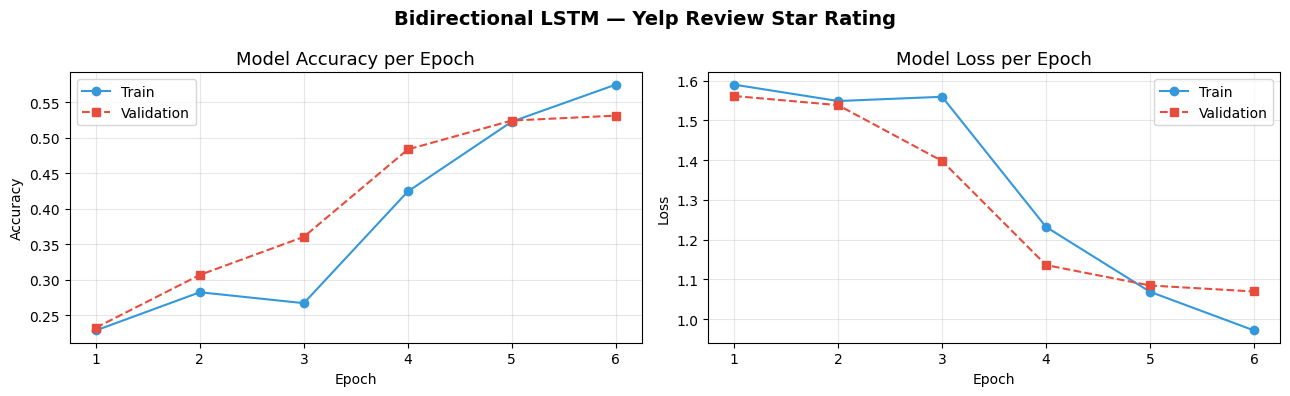

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_range, history.history['accuracy'],     'o-', label='Train', color='#3498db')
axes[0].plot(epochs_range, history.history['val_accuracy'], 's--', label='Validation', color='#e74c3c')
axes[0].set_title('Model Accuracy per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history.history['loss'],     'o-', label='Train', color='#3498db')
axes[1].plot(epochs_range, history.history['val_loss'], 's--', label='Validation', color='#e74c3c')
axes[1].set_title('Model Loss per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Bidirectional LSTM — Yelp Review Star Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()

## Step 9 — Confusion Matrix & Classification Report

Classification Report:
              precision    recall  f1-score   support

          1★       0.67      0.72      0.70      2010
          2★       0.46      0.41      0.43      2028
          3★       0.42      0.59      0.49      1994
          4★       0.45      0.41      0.43      2016
          5★       0.72      0.52      0.60      1952

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.54      0.53      0.53     10000



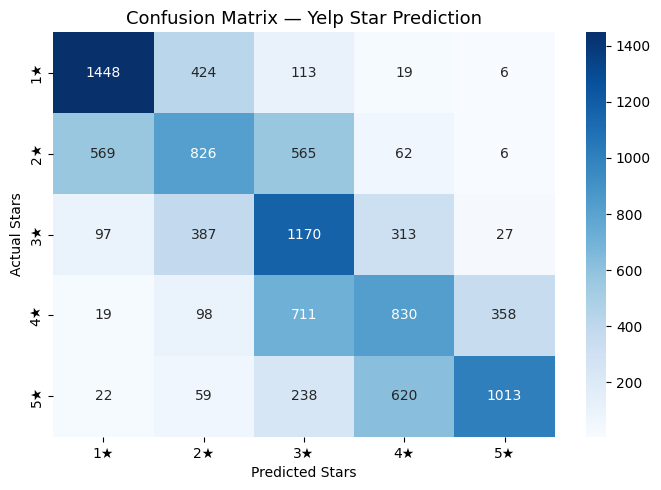

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['1★','2★','3★','4★','5★']
))

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1★','2★','3★','4★','5★'],
            yticklabels=['1★','2★','3★','4★','5★'])
plt.title('Confusion Matrix — Yelp Star Prediction', fontsize=13)
plt.ylabel('Actual Stars'); plt.xlabel('Predicted Stars')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

## Step 10 — Predict on Custom Review

In [16]:
def predict_stars(review_text):
    cleaned  = clean_text(review_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = model.predict(padded, verbose=0)[0]
    pred_star = np.argmax(probs) + 1
    star_bar  = '★' * pred_star + '☆' * (5 - pred_star)
    print(f'Review   : "{review_text[:80]}..."' if len(review_text) > 80 else f'Review   : "{review_text}"')
    print(f'Predicted: {star_bar} ({pred_star}/5 stars)')
    print(f'Confidence: {probs[pred_star-1]*100:.1f}%')
    print('-' * 60)

predict_stars('Absolutely amazing food! Best burger I have ever had. Will definitely come back!')
predict_stars('Terrible experience. Rude staff, cold food, and overpriced. Never going back.')
predict_stars('It was decent. Nothing special but the price was fair and food came quickly.')
predict_stars('Pretty good overall. The pasta was great but service was a bit slow.')

Review   : "Absolutely amazing food! Best burger I have ever had. Will definitely come back!"
Predicted: ★★★★★ (5/5 stars)
Confidence: 83.4%
------------------------------------------------------------
Review   : "Terrible experience. Rude staff, cold food, and overpriced. Never going back."
Predicted: ★☆☆☆☆ (1/5 stars)
Confidence: 80.2%
------------------------------------------------------------
Review   : "It was decent. Nothing special but the price was fair and food came quickly."
Predicted: ★★★☆☆ (3/5 stars)
Confidence: 54.1%
------------------------------------------------------------
Review   : "Pretty good overall. The pasta was great but service was a bit slow."
Predicted: ★★★☆☆ (3/5 stars)
Confidence: 48.8%
------------------------------------------------------------


## Step 11 — Save the Model

In [17]:
model.save('bilstm_yelp_model.keras')
print('✅ Model saved as bilstm_yelp_model.keras')

import pickle
with open('tokenizer_yelp.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('✅ Tokenizer saved as tokenizer_yelp.pkl')

# To reload:
# from tensorflow.keras.models import load_model
# import pickle
# model     = load_model('bilstm_yelp_model.keras')
# tokenizer = pickle.load(open('tokenizer_yelp.pkl', 'rb'))

✅ Model saved as bilstm_yelp_model.keras
✅ Tokenizer saved as tokenizer_yelp.pkl
